## Week7 - Part2: Zero-Shot Learning With CLIP
In this notebook, we will explore how to use CLIP for zero-shot classification. We will use the `CLIPProcessor` and `CLIPModel` from the `transformers` library to perform zero-shot classification on a test image.

In [18]:
import tensorflow as tf
import numpy as np
import tensorflow.keras.ops as ops
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import matplotlib.pyplot as plt

## Load CLIP model and processor from Hugging Face
First, we will load the CLIP model and processor from the `transformers` library. The `CLIPProcessor` is used to preprocess the input image and text, while the `CLIPModel` is used to perform zero-shot classification.


In [14]:
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")

## Load the Test Image
We will load a test image from code directory. You can replace the image path with any image you want to test.

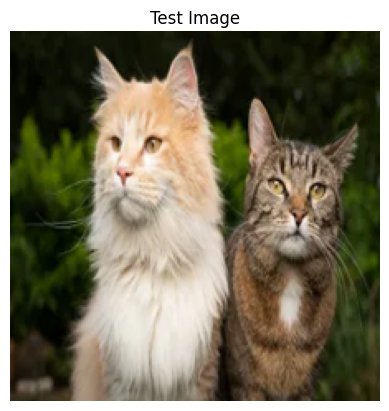

In [20]:
image_path = "Test_data.jpg" 
img = Image.open(image_path)
img = img.resize((224, 224))

plt.imshow(img)
plt.axis('off')
plt.title("Test Image")
plt.show()

## Encoding The Image and Text Using CLIP
We will use the `CLIPProcessor` to preprocess the image and text labels. The processor will convert the image and text into the format required by the CLIP model.

In [23]:
# Encode the image using CLIP
inputs = processor(images=img, return_tensors="pt", padding=True)
image_features = model.get_image_features(**inputs)

# Encode the text (class labels) using CLIP
candidate_labels_set1 = ["a photo of a cat", "a photo of a dog", "a picture of a person", "a photo of a car"]
candidate_labels_set2 = ["a photo of a cat", "a photo of a dog", "a photo of two cats" , "a photo of two dogs"]

candidate_labels = candidate_labels_set1
inputs = processor(text=candidate_labels, return_tensors="pt", padding=True)
text_features = model.get_text_features(**inputs)

## Calculate similarity between image features and text features
In the final step, we will calculate the similarity between the image features and text features. The text label with the highest similarity score will be the predicted label for the image.

In [24]:
# Detach tensors from the computation graph
image_features = image_features.detach().numpy()
text_features = text_features.detach().numpy()

# Normalize the features (l2-normalize)
image_features = image_features / np.linalg.norm(image_features, axis=-1, keepdims=True)
text_features = text_features / np.linalg.norm(text_features, axis=-1, keepdims=True)

# Compute similarity
similarity_scores = np.matmul(image_features, text_features.T)

# Get the index of the most similar label
predicted_label_idx = np.argmax(similarity_scores, axis=-1).item()
predicted_label = candidate_labels[predicted_label_idx]

print(f"Predicted label: {predicted_label}")

Predicted label: a photo of a cat
